In [ ]:
"""
Basketball-Reference Season-Level Player Stats Scraper
=======================================================
Scrapes regular season totals per player per team per season (1960-2026),
then aggregates to decade-level per-game averages with position percentages.
 
Output columns:
    Team, Decade, Player, Games, PPG, RPG, APG, SPG, BPG,
    PG%, SG%, SF%, PF%, C%
 
Position % logic:
  - Players WITH play-by-play data: minute-weighted average of pct_1..pct_5
    across all seasons in the decade for that team.
  - Players WITHOUT PBP data: 0/1 based on whether they were ever listed at
    that position on any roster in that team-decade.
 
Usage
-----
    pip install requests beautifulsoup4 pandas
    python bball_ref_scraper.py                   # full run
    python bball_ref_scraper.py --resume          # skip seasons already cached
    python bball_ref_scraper.py --aggregate-only  # re-aggregate without re-scraping
 
Notes
-----
* Steals and blocks were not officially tracked until 1973-74; those columns
  will be 0 for earlier seasons (matching the source data).
* Basketball-Reference requests a crawl delay of at least 3 s between requests.
  The default REQUEST_DELAY is 4 s.
* A checkpoint raw CSV is written after every season so an interrupted run
  can be resumed with --resume.
* Player PBP pages are scraped once per unique player URL per team-decade,
  not once per season, to minimise requests.
"""
 
import argparse
import re
import logging
import time
from pathlib import Path
 
import requests
from bs4 import BeautifulSoup, Comment
import pandas as pd
import matplotlib.pyplot as plt
 
# ── Configuration ──────────────────────────────────────────────────────────────
 
START_YEAR = 1960
END_YEAR   = 2026
 
REQUEST_DELAY = 4.0   # seconds between HTTP requests
 
RAW_FILE    = Path("nba_player_stats_raw.csv")
OUTPUT_FILE = Path("nba_player_stats_by_decade.csv")
BASE_URL    = "https://www.basketball-reference.com"
 
POS_COLS    = ["PG%", "SG%", "SF%", "PF%", "C%"]   # pct_1 … pct_5
PBP_STATS   = ["pct_1", "pct_2", "pct_3", "pct_4", "pct_5"]
 
# ── Logging ────────────────────────────────────────────────────────────────────
 
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

 
# ── HTTP session ───────────────────────────────────────────────────────────────
 
_SESSION = requests.Session()
_SESSION.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/125.0.0.0 Safari/537.36"
    ),
    "Accept":          "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection":      "keep-alive",
})

In [51]:
def _get(url: str, retries: int = 4, backoff: float = 15.0) -> BeautifulSoup | None:
    """GET *url* with exponential back-off on 429. Returns BeautifulSoup or None."""
    for attempt in range(1, retries + 1):
        try:
            resp = _SESSION.get(url, timeout=30)
            if resp.status_code == 200:
                return BeautifulSoup(resp.text, "html.parser")
            if resp.status_code == 429:
                wait = backoff * (2 ** (attempt - 1))
                log.warning("Rate-limited (429). Sleeping %.0f s …", wait)
                time.sleep(wait)
                continue
            log.warning("HTTP %s for %s (attempt %d/%d)",
                        resp.status_code, url, attempt, retries)
            return None
        except requests.RequestException as exc:
            log.warning("Network error (attempt %d/%d): %s", attempt, retries, exc)
            time.sleep(backoff * attempt)
    log.error("Giving up after %d attempts: %s", retries, url)
    return None
 
 
# ── Utilities ──────────────────────────────────────────────────────────────────
 
def _to_int(value) -> int:
    try:
        return int(str(value).strip())
    except (ValueError, TypeError):
        return 0
 
 
def _to_float(value) -> float:
    try:
        return float(str(value).strip())
    except (ValueError, TypeError):
        return 0.0
 
 
def _decade(year: int) -> str:
    return f"{(year // 10) * 10}s"
 
 
def _uncomment_tables(soup: BeautifulSoup) -> BeautifulSoup:
    """Promote Basketball-Reference's comment-hidden tables to real DOM nodes."""
    for comment in soup.find_all(string=lambda t: isinstance(t, Comment)):
        if "<table" in comment:
            frag = BeautifulSoup(comment, "html.parser")
            children = list(frag.body.children if frag.body else frag.children)
            comment.replace_with(*children)
    return soup
 
 
# ── Team discovery ─────────────────────────────────────────────────────────────
 
def get_teams_for_season(season_end_year: int) -> list[dict]:
    """Return [{abbr, name}, ...] for every team in *season_end_year*."""
    url = f"{BASE_URL}/leagues/NBA_{season_end_year}.html"
    soup = _get(url)
    if soup is None:
        return []
 
    seen:  set[str]   = set()
    teams: list[dict] = []
    pattern = re.compile(r"^/teams/([A-Z]{2,3})/(\d{4})\.html$")
    for a in soup.select("a[href]"):
        m = pattern.match(a["href"])
        if m and int(m.group(2)) == season_end_year:
            abbr = m.group(1)
            if abbr not in seen:
                seen.add(abbr)
                teams.append({"abbr": abbr, "name": a.get_text(strip=True)})
    return teams
 
 
# ── Stats table helpers ────────────────────────────────────────────────────────
 
def _find_stats_table(soup: BeautifulSoup, abbr: str, season_end_year: int):
    """Find the best available player-totals table on a team-season page."""
    for tid in ("totals_stats", "totals", "per_game_stats", "per_game", "stats", "players"):
        t = soup.find("table", {"id": tid})
        if t:
            if tid != "totals_stats":
                log.info("  Using fallback table id=%r for %s %d", tid, abbr, season_end_year)
            return t
    for wrapper_id in ("div_totals_stats", "div_totals", "div_per_game_stats", "div_per_game"):
        wrapper = soup.find(id=wrapper_id)
        if wrapper:
            t = wrapper.find("table")
            if t:
                log.info("  Using first table in #%s for %s %d", wrapper_id, abbr, season_end_year)
                return t
    log.warning("No stats table found: %s %d", abbr, season_end_year)
    return None
 
 
def get_team_season_totals(abbr: str, season_end_year: int) -> list[dict]:
    """
    Scrape totals + roster position for one team-season.
    Returns list of dicts with Player, PlayerURL, RosterPos, Games, and raw
    stat totals (Points, Rebounds, Assists, Steals, Blocks, Minutes).
    """
    url = f"{BASE_URL}/teams/{abbr}/{season_end_year}.html"
    soup = _get(url)
    if soup is None:
        return []
    soup = _uncomment_tables(soup)
 
    # ── Totals table ──────────────────────────────────────────────────────────
    table = _find_stats_table(soup, abbr, season_end_year)
    if table is None:
        return []
 
    # ── Roster table → player → position mapping ──────────────────────────────
    roster_pos: dict[str, str] = {}
    roster_table = soup.find("table", {"id": "roster"})
    if roster_table:
        for tr in roster_table.select("tbody tr"):
            p_tag = tr.find(attrs={"data-stat": "player"})
            pos_tag = tr.find(attrs={"data-stat": "pos"})
            if p_tag and pos_tag:
                roster_pos[p_tag.get_text(strip=True)] = pos_tag.get_text(strip=True)
 
    rows: list[dict] = []
    for tr in table.select("tbody tr"):
        if "thead" in tr.get("class", []):
            continue
 
        def cell(stat: str) -> str:
            tag = tr.find(attrs={"data-stat": stat})
            return tag.get_text(strip=True) if tag else ""
 
        player = cell("name_display") or cell("player")
        if not player or player.lower() == "team totals":
            continue
        if cell("pts") == "" and cell("trb") == "":
            continue
 
        # Player page URL from the anchor inside the name cell
        player_url = ""
        name_tag = tr.find(attrs={"data-stat": "name_display"}) or tr.find(attrs={"data-stat": "player"})
        if name_tag:
            a = name_tag.find("a")
            if a and a.get("href"):
                player_url = a["href"]
 
        rows.append({
            "Player":    player,
            "PlayerURL": player_url,
            "RosterPos": roster_pos.get(player, ""),
            "Games":     _to_int(cell("games")),
            "Minutes":   _to_int(cell("mp")),
            "Points":    _to_int(cell("pts")),
            "Rebounds":  _to_int(cell("trb")),
            "Assists":   _to_int(cell("ast")),
            "Steals":    _to_int(cell("stl")),
            "Blocks":    _to_int(cell("blk")),
        })
 
    return rows
 
 
# ── Player PBP position percentages ───────────────────────────────────────────
 
def get_player_pbp_positions(player_url: str, decade: str) -> dict | None:
    """
    Scrape the play-by-play table from a player's page and return
    minute-weighted position percentages for seasons in *decade*.
 
    Returns dict with keys PG%, SG%, SF%, PF%, C%  (0-1 scale),
    or None if no PBP data is available.
    """
    url = f"{BASE_URL}{player_url}"
    soup = _get(url)
    if soup is None:
        return None
    soup = _uncomment_tables(soup)
 
    pbp_table = soup.find("table", {"id": "pbp_stats"})
    if pbp_table is None:
        return None
 
    decade_start = int(decade[:-1])   # "1960s" → 1960
    decade_end   = decade_start + 9
 
    total_minutes = 0.0
    weighted = [0.0] * 5   # pct_1 … pct_5
 
    for tr in pbp_table.select("tbody tr"):
        if "thead" in tr.get("class", []):
            continue
 
        def cell(stat: str) -> str:
            tag = tr.find(attrs={"data-stat": stat})
            return tag.get_text(strip=True) if tag else ""
 
        # year_id looks like "2025-26"; season end year is the second part
        year_id = cell("year_id")
        if not year_id or year_id == "Career":
            continue
        try:
            season_end = int(year_id.split("-")[1])
            # Handle two-digit year suffix: "99" → 1999, "00" → 2000
            if season_end < 50:
                season_end += 2000
            else:
                season_end += 1900 if season_end > 99 else 0
            # Reparse properly: "1999-00" → end year 2000
            parts = year_id.split("-")
            base  = int(parts[0])
            suffix = int(parts[1])
            season_end = base + 1 if suffix != 99 else base + 1
            # Simpler: end year = start year + 1 always
            season_end = int(parts[0]) + 1
        except (ValueError, IndexError):
            continue
 
        if not (decade_start <= season_end <= decade_end + 1):
            continue
 
        # Skip rows for other teams if player was traded (keep all — mp weighted)
        mp = _to_float(cell("mp"))
        if mp == 0:
            continue
 
        for i, stat in enumerate(PBP_STATS):
            val = cell(stat)
            # Values are stored as integers 0-100 on the site
            pct = _to_float(val) / 100.0 if val else 0.0
            weighted[i] += pct * mp
 
        total_minutes += mp
 
    if total_minutes == 0:
        return None
 
    return {
        col: round(weighted[i] / total_minutes, 4)
        for i, col in enumerate(POS_COLS)
    }
 
 
def _roster_pos_to_binary(roster_positions: set[str]) -> dict:
    """
    Convert a set of roster position strings (e.g. {"PF", "C"}) to binary
    position columns.  Matches on the standard abbreviation appearing anywhere
    in the position string to handle combined entries like "PF-C".
    """
    mapping = {"PG%": "PG", "SG%": "SG", "SF%": "SF", "PF%": "PF", "C%": "C"}
    return {
        col: (1 if any(abbr in pos for pos in roster_positions) else 0)
        for col, abbr in mapping.items()
    }
 
 
# ── Scraping orchestration ─────────────────────────────────────────────────────
 
def scrape_all(resume: bool = False) -> pd.DataFrame:
    """
    Scrape every season × every team. Returns raw player-season DataFrame.
    Checkpoints to RAW_FILE after every season.
    """
    existing:     pd.DataFrame = pd.DataFrame()
    done_seasons: set[int]     = set()
 
    if resume and RAW_FILE.exists():
        existing     = pd.read_csv(RAW_FILE)
        done_seasons = set(existing["Season"].unique())
        log.info("Resuming: %d seasons already cached.", len(done_seasons))
 
    todo = [y for y in range(START_YEAR, END_YEAR + 1) if y not in done_seasons]
    log.info("Seasons to scrape: %d  (range %d–%d)", len(todo), START_YEAR, END_YEAR)
 
    new_records: list[dict] = []
 
    for season_year in todo:
        decade = _decade(season_year)
        log.info("=== Season %d (%s) ===", season_year, decade)
 
        teams = get_teams_for_season(season_year)
        time.sleep(REQUEST_DELAY)
 
        if not teams:
            log.warning("No teams found for %d – skipping.", season_year)
            continue
 
        for team in teams:
            abbr, name = team["abbr"], team["name"]
            log.info("  %-30s (%s)", name, abbr)
            player_rows = get_team_season_totals(abbr, season_year)
            time.sleep(REQUEST_DELAY)
 
            for row in player_rows:
                new_records.append({
                    "Team":     name,
                    "TeamAbbr": abbr,
                    "Season":   season_year,
                    "Decade":   decade,
                    **row,
                })
 
        log.info("  → %d cumulative player-rows", len(new_records))
 
        checkpoint = pd.concat(
            [existing, pd.DataFrame(new_records)],
            ignore_index=True,
        )
        checkpoint.to_csv(RAW_FILE, index=False)
        log.info("  Checkpoint → %s", RAW_FILE)
 
    raw_df = (
        pd.concat([existing, pd.DataFrame(new_records)], ignore_index=True)
        if new_records else existing.copy()
    )
    log.info("Total raw records: %d", len(raw_df))
    return raw_df
 
 
# ── Aggregation ────────────────────────────────────────────────────────────────
 
def aggregate_by_decade(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each (Team, Decade, Player):
      - Sum Games, Minutes, Points, Rebounds, Assists, Steals, Blocks
      - Compute per-game averages (PPG, RPG, APG, SPG, BPG)
      - Scrape PBP position % from player page (minute-weighted across decade)
        or fall back to binary roster position encoding
    """
    group_cols = ["Team", "Decade", "Player", "PlayerURL"]
 
    # Collect all roster positions seen per (Team, Decade, Player)
    roster_agg = (
        df[df["RosterPos"] != ""]
        .groupby(["Team", "Decade", "Player"])["RosterPos"]
        .apply(set)
        .reset_index()
        .rename(columns={"RosterPos": "RosterPosSet"})
    )
 
    agg = (
        df.groupby(group_cols, sort=False, as_index=False)
        .agg(
            Games    = ("Games",    "sum"),
            Minutes  = ("Minutes",  "sum"),
            Points   = ("Points",   "sum"),
            Rebounds = ("Rebounds", "sum"),
            Assists  = ("Assists",  "sum"),
            Steals   = ("Steals",   "sum"),
            Blocks   = ("Blocks",   "sum"),
        )
    )
 
    agg = agg.merge(roster_agg, on=["Team", "Decade", "Player"], how="left")
 
    # ── Per-game averages ─────────────────────────────────────────────────────
    for raw_col, avg_col in [
        ("Points",   "PPG"),
        ("Rebounds", "RPG"),
        ("Assists",  "APG"),
        ("Steals",   "SPG"),
        ("Blocks",   "BPG"),
    ]:
        agg[avg_col] = (agg[raw_col] / agg["Games"].replace(0, pd.NA)).round(2)
 
    # ── Position percentages ──────────────────────────────────────────────────
    # Cache player PBP lookups: (PlayerURL, Decade) → pos dict or None
    pbp_cache: dict[tuple, dict | None] = {}
 
    pos_records = []
    total = len(agg)
    for i, row in agg.iterrows():
        if (i + 1) % 100 == 0:
            log.info("  Position lookup %d / %d …", i + 1, total)
 
        player_url = row["PlayerURL"]
        decade     = row["Decade"]
        cache_key  = (player_url, decade)
 
        if player_url and cache_key not in pbp_cache:
            log.debug("  PBP scrape: %s (%s)", row["Player"], decade)
            pbp_cache[cache_key] = get_player_pbp_positions(player_url, decade)
            time.sleep(REQUEST_DELAY)
 
        pbp = pbp_cache.get(cache_key) if player_url else None
 
        if pbp is not None:
            pos_records.append(pbp)
        else:
            # Fallback: binary from roster positions
            roster_set = row.get("RosterPosSet") or set()
            pos_records.append(_roster_pos_to_binary(roster_set))
 
    pos_df = pd.DataFrame(pos_records, index=agg.index)
    agg = pd.concat([agg, pos_df], axis=1)
 
    # ── Final output ──────────────────────────────────────────────────────────
    out_cols = ["Team", "Decade", "Player", "Games",
                "PPG", "RPG", "APG", "SPG", "BPG",
                "PG%", "SG%", "SF%", "PF%", "C%"]
 
    return (
        agg[out_cols]
        .sort_values(["Team", "Decade", "PPG"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

In [52]:
raw_df = scrape_all(resume=False)   # change to True to resume a prior run
result = aggregate_by_decade(raw_df)
result.to_csv(OUTPUT_FILE, index=False)
result.head(20)

2026-06-13 21:20:58,210 INFO Seasons to scrape: 67  (range 1960–2026)
2026-06-13 21:20:58,212 INFO === Season 1960 (1960s) ===
2026-06-13 21:21:02,689 INFO   Boston Celtics                 (BOS)
2026-06-13 21:21:07,144 INFO   Philadelphia Warriors          (PHW)
2026-06-13 21:21:11,517 INFO   Syracuse Nationals             (SYR)
2026-06-13 21:21:15,979 INFO   New York Knicks                (NYK)
2026-06-13 21:21:20,478 INFO   St. Louis Hawks                (STL)
2026-06-13 21:21:24,934 INFO   Detroit Pistons                (DET)
2026-06-13 21:21:29,234 INFO   Minneapolis Lakers             (MNL)
2026-06-13 21:21:33,732 INFO   Cincinnati Royals              (CIN)
2026-06-13 21:21:38,088 INFO   → 111 cumulative player-rows
2026-06-13 21:21:38,115 INFO   Checkpoint → nba_player_stats_raw.csv
2026-06-13 21:21:38,117 INFO === Season 1961 (1960s) ===
2026-06-13 21:21:42,387 INFO   Boston Celtics                 (BOS)
2026-06-13 21:21:46,837 INFO   Philadelphia Warriors          (PHW)
2026-06

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%
0,Atlanta Hawks,1960s,Lou Hudson,81,21.85,6.58,2.67,0.00,0.00,0.0,0.0,1.0,0.0,0.0
1,Atlanta Hawks,1960s,Zelmo Beaty,72,21.47,11.08,1.82,0.00,0.00,0.0,0.0,0.0,0.0,1.0
2,Atlanta Hawks,1960s,Joe Caldwell,81,15.81,3.74,3.95,0.00,0.00,0.0,1.0,0.0,0.0,0.0
3,Atlanta Hawks,1960s,Don Ohl,76,12.07,2.24,2.91,0.00,0.00,0.0,1.0,0.0,0.0,0.0
4,Atlanta Hawks,1960s,Bill Bridges,80,11.76,14.15,3.72,0.00,0.00,0.0,0.0,0.0,1.0,0.0
5,Atlanta Hawks,1960s,Walt Hazzard,80,11.22,3.32,5.92,0.00,0.00,1.0,0.0,0.0,0.0,0.0
6,Atlanta Hawks,1960s,Jim Davis,78,8.77,6.78,1.24,0.00,0.00,0.0,0.0,0.0,0.0,1.0
7,Atlanta Hawks,1960s,Paul Silas,79,8.68,9.43,1.77,0.00,0.00,0.0,0.0,0.0,1.0,0.0
8,Atlanta Hawks,1960s,Richie Guerin,27,5.59,2.19,3.67,0.00,0.00,0.0,1.0,0.0,0.0,0.0
9,Atlanta Hawks,1960s,George Lehmann,11,5.45,0.82,2.45,0.00,0.00,1.0,0.0,0.0,0.0,0.0


In [1]:
import pandas as pd
raw_stats = pd.read_csv('nba_player_stats_raw.csv')
print(len(raw_stats))
raw_stats.head()

26957


,Team,TeamAbbr,Season,Decade,Player,PlayerURL,RosterPos,Games,Minutes,Points,Rebounds,Assists,Steals,Blocks
0,Boston Celtics,BOS,1960,1960s,Bill Russell,/players/r/russebi01.html,C,74,3146,1350,1778,277,0,0
1,Boston Celtics,BOS,1960,1960s,Bob Cousy,/players/c/cousybo01.html,PG,75,2588,1455,352,715,0,0
2,Boston Celtics,BOS,1960,1960s,Tom Heinsohn,/players/h/heinsto01.html,PF,75,2420,1629,794,171,0,0
3,Boston Celtics,BOS,1960,1960s,Frank Ramsey,/players/r/ramsefr01.html,SG,73,2009,1117,506,137,0,0
4,Boston Celtics,BOS,1960,1960s,Bill Sharman,/players/s/sharmbi01.html,SG,71,1916,1370,262,144,0,0


In [2]:
decade_stats = pd.read_csv('nba_player_stats_by_decade.csv')
print(len(decade_stats))
decade_stats.head()

14369


,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%
0,Atlanta Hawks,1960s,Lou Hudson,81,21.85,6.58,2.67,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Atlanta Hawks,1960s,Zelmo Beaty,72,21.47,11.08,1.82,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Atlanta Hawks,1960s,Joe Caldwell,81,15.81,3.74,3.95,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Atlanta Hawks,1960s,Don Ohl,76,12.07,2.24,2.91,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Atlanta Hawks,1960s,Bill Bridges,80,11.76,14.15,3.72,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [3]:
# Team name mapping
team_name_mapping = {
    "New Jersey Nets": "Brooklyn Nets",
    "Seattle SuperSonics": "Oklahoma City Thunder",
    "New Orleans Hornets": "New Orleans Pelicans",
    "Washington Bullets": "Washington Wizards",
    "Charlotte Bobcats": "Charlotte Hornets",
    "Cincinnati Royals": "Sacramento Kings",
    "Kansas City Kings": "Sacramento Kings",
    "Baltimore Bullets": "Washington Wizards",
    "Buffalo Braves": "Los Angeles Clippers",
    "San Diego Clippers": "Los Angeles Clippers",
    "Vancouver Grizzlies": "Memphis Grizzlies",
    "St. Louis Hawks": "Atlanta Hawks",
    "San Francisco Warriors": "Golden State Warriors",
    "New Orleans Jazz": "Utah Jazz",
    "San Diego Rockets": "Houston Rockets",
    "Kansas City-Omaha Kings": "Sacramento Kings",
    "Syracuse Nationals": "Philadelphia 76ers",
    "New Orleans/Oklahoma City Hornets": "New Orleans Pelicans",
    "Philadelphia Warriors": "Golden State Warriors",
    "New York Nets": "Brooklyn Nets",
    "Chicago Zephyrs": "Washington Wizards",
    "Chicago Packers": "Washington Wizards",
    "Minneapolis Lakers": "Los Angeles Lakers",
    "Capital Bullets": "Washington Wizards",
}

# Step 1: Rename teams
decade_stats["Team"] = decade_stats["Team"].replace(team_name_mapping)

# Step 2: Re-aggregate — weighted averages using Games as weight
stat_cols = ["PPG", "RPG", "APG", "SPG", "BPG"]
pos_cols = ["PG%", "SG%", "SF%", "PF%", "C%"]

def weighted_agg(group):
    total_games = group["Games"].sum()
    result = {"Games": total_games}
    for col in stat_cols + pos_cols:
        result[col] = (group[col] * group["Games"]).sum() / total_games
    return pd.Series(result)

decade_stats = (
    decade_stats
    .groupby(["Team", "Decade", "Player"], as_index=False)
    .apply(weighted_agg)
)

decade_stats['Team'].value_counts()

<positron-console-cell-3>:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Team
Philadelphia 76ers        623
Washington Wizards        588
Atlanta Hawks             584
Sacramento Kings          576
Los Angeles Clippers      567
Detroit Pistons           562
Golden State Warriors     559
New York Knicks           549
Brooklyn Nets             547
Milwaukee Bucks           544
Los Angeles Lakers        528
Cleveland Cavaliers       524
Phoenix Suns              515
Houston Rockets           511
Boston Celtics            501
Chicago Bulls             495
Oklahoma City Thunder     467
Portland Trail Blazers    457
Dallas Mavericks          447
San Antonio Spurs         446
Denver Nuggets            432
Utah Jazz                 414
Indiana Pacers            395
Charlotte Hornets         371
Miami Heat                349
Memphis Grizzlies         345
Minnesota Timberwolves    338
Toronto Raptors           338
Orlando Magic             324
New Orleans Pelicans      275
Name: count, dtype: int64

(array([3.602e+03, 4.759e+03, 3.146e+03, 1.668e+03, 7.030e+02, 2.240e+02,
        5.600e+01, 1.100e+01, 0.000e+00, 2.000e+00]),
 array([ 0.        ,  3.42167462,  6.84334923, 10.26502385, 13.68669846,
        17.10837308, 20.53004769, 23.95172231, 27.37339692, 30.79507154,
        34.21674615]),
 <BarContainer object of 10 artists>)

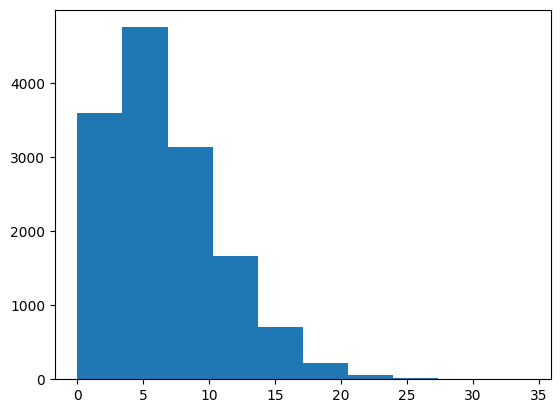

In [4]:
import matplotlib.pyplot as plt

pre_tracking_decades = {"1960s", "1970s"}  # steals/blocks officially tracked from 1973-74

def calculate_value(row):
    if row["Decade"] in pre_tracking_decades:
        return 0.34 * row["PPG"] + 0.59 * row["RPG"] + 0.63 * row["APG"] + 3.4
    else:
        return 0.34 * row["PPG"] + 0.59 * row["RPG"] + 0.63 * row["APG"] + 1.29 * row["SPG"] + 1.55 * row["BPG"]

decade_stats["Value"] = decade_stats.apply(calculate_value, axis=1)
plt.hist(decade_stats['Value'])

In [5]:
decade_stats.sort_values('Value', ascending=False).head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value
4516,Golden State Warriors,1960s,Wilt Chamberlain,429.0,41.450000,25.099231,3.040000,0.00,0.00,0.0000,0.0000,0.0000,0.0000,1.0000,34.216746
10262,Philadelphia 76ers,1960s,Wilt Chamberlain,277.0,27.620000,23.940000,6.780000,0.00,0.00,0.0000,0.0000,0.0000,0.0000,1.0000,31.186800
6550,Los Angeles Lakers,1960s,Wilt Chamberlain,81.0,20.540000,21.140000,4.520000,0.00,0.00,0.0000,0.0000,0.0000,0.0000,1.0000,25.703800
7774,Milwaukee Bucks,1970s,Kareem Abdul-Jabbar,467.0,30.430000,15.330000,4.300000,0.38,1.06,0.0000,0.0000,0.0000,0.0000,1.0000,25.499900
11848,Sacramento Kings,1960s,Oscar Robertson,683.0,29.660000,8.720000,10.500000,0.00,0.00,1.0000,0.0000,0.0000,0.0000,0.0000,25.244200
8,Atlanta Hawks,1960s,Bob Pettit,435.0,27.550000,16.680000,3.310000,0.00,0.00,0.0000,0.0000,0.0000,1.0000,0.0000,24.693500
587,Boston Celtics,1960s,Bill Russell,776.0,14.830000,22.550000,4.620000,0.00,0.00,0.0000,0.0000,0.0000,0.0000,1.0000,24.657300
5199,Houston Rockets,1990s,Hakeem Olajuwon,689.0,23.920000,11.610000,3.020000,1.78,3.46,0.0000,0.0000,0.0000,0.0000,1.0000,24.544500
3878,Denver Nuggets,2020s,Nikola JokiÄ,502.0,25.900000,12.010000,8.950000,1.40,0.73,0.0000,0.0000,0.0000,0.0014,0.9986,24.467900
12531,San Antonio Spurs,1990s,David Robinson,685.0,24.400000,11.510000,2.960000,1.57,3.39,0.0000,0.0000,0.0000,0.0000,1.0000,24.231500


In [28]:
import pandas as pd
import numpy as np
import random

# Get all valid current NBA teams from the dataset
valid_teams = decade_stats["Team"].unique().tolist()
valid_decades = ["1960s", "1970s", "1980s", "1990s", "2000s", "2010s", "2020s"]

position_cols = ["PG%", "SG%", "SF%", "PF%", "C%"]
position_names = ["PG", "SG", "SF", "PF", "C"]

def run_simulation():
    roster = {pos: None for pos in position_names}
    filled_positions = set()
    used_decade_team_combos = set()

    for _ in range(5):
        # Keep trying team/decade combos until we find one with a valid player
        # for an open position
        max_attempts = 100
        player_assigned = False

        for attempt in range(max_attempts):
            team = random.choice(valid_teams)
            decade = random.choice(valid_decades)
            combo = (team, decade)

            if combo in used_decade_team_combos:
                continue

            candidates = decade_stats[
                (decade_stats["Team"] == team) &
                (decade_stats["Decade"] == decade)
            ].copy()

            if candidates.empty:
                continue

            candidates = candidates.sort_values("Value", ascending=False)

            open_positions = [p for p in position_names if p not in filled_positions]

            # Find highest-value player who has any affinity for an open position
            for _, player in candidates.iterrows():
                pos_scores = {p: player[f"{p}%"] for p in open_positions}

                # Skip player if they have 0% in all open positions
                if max(pos_scores.values()) == 0:
                    continue

                best_pos = max(pos_scores, key=pos_scores.get)
                roster[best_pos] = player
                filled_positions.add(best_pos)
                used_decade_team_combos.add(combo)
                player_assigned = True
                break

            if player_assigned:
                break

        if not player_assigned:
            return None  # Safety valve — discard this simulation

    # Build result row
    row = {}
    total_value = 0

    for pos in position_names:
        player = roster[pos]
        label = f"{player['Player']} - {player['Team']} {player['Decade']}"
        row[pos] = label
        row[f"{pos} Value"] = round(player["Value"], 4)
        total_value += player["Value"]

    row["Total Value"] = round(total_value, 4)
    row["Total Wins"] = round(0.83 * total_value - 9.6, 4)

    return row

# Run until we have 100000 complete rosters
results = []
while len(results) < 100000:
    row = run_simulation()
    if row is not None:
        results.append(row)

results_df = pd.DataFrame(results, columns=[
    "PG", "PG Value",
    "SG", "SG Value",
    "SF", "SF Value",
    "PF", "PF Value",
    "C",  "C Value",
    "Total Value", "Total Wins"
])

print(f"\nAverage Total Wins: {results_df['Total Wins'].mean():.2f}")
print(f"Max Total Wins: {results_df['Total Wins'].max():.2f}")

KeyboardInterrupt: 

In [ ]:
results_df.to_csv('simulations-100k.csv')

In [6]:
results_df = pd.read_csv('simulations-100k.csv')

In [7]:
results_df.sort_values(['Total Wins'], ascending=False)

,Unnamed: 0,PG,PG Value,SG,SG Value,SF,SF Value,PF,PF Value,C,C Value,Total Value,Total Wins
98096,98096,James Harden - Brooklyn Nets 2020s,22.1824,Michael Jordan - Chicago Bulls 1980s,23.9208,Elgin Baylor - Los Angeles Lakers 1960s,23.7784,Truck Robinson - Utah Jazz 1970s,21.3290,Wilt Chamberlain - Philadelphia 76ers 1960s,31.1868,122.3974,91.9898
70746,70746,James Harden - Houston Rockets 2020s,23.6401,Tracy McGrady - Orlando Magic 2000s,20.4843,Tim Duncan - San Antonio Spurs 1990s,20.7036,Kevin Garnett - Minnesota Timberwolves 2000s,22.5977,Wilt Chamberlain - Golden State Warriors 1960s,34.2167,121.6424,91.3632
22910,22910,Oscar Robertson - Sacramento Kings 1970s,20.7197,Shai Gilgeous-Alexander - Oklahoma City Thunde...,19.2776,Elgin Baylor - Los Angeles Lakers 1960s,23.7784,DeMarcus Cousins - New Orleans Pelicans 2010s,23.4679,Wilt Chamberlain - Golden State Warriors 1960s,34.2167,121.4603,91.2121
4568,4568,Chris Paul - New Orleans Pelicans 2000s,18.8874,Michael Jordan - Chicago Bulls 1980s,23.9208,Elton Brand - Los Angeles Clippers 2000s,19.4048,Bob Pettit - Atlanta Hawks 1960s,24.6935,Wilt Chamberlain - Golden State Warriors 1960s,34.2167,121.1232,90.9323
80073,80073,James Harden - Brooklyn Nets 2020s,22.1824,Russell Westbrook - Washington Wizards 2020s,24.0728,Connie Hawkins - Phoenix Suns 1970s,18.4003,Chris Webber - Sacramento Kings 1990s,22.1777,Wilt Chamberlain - Golden State Warriors 1960s,34.2167,121.0499,90.8715
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38113,38113,Sleepy Floyd - Houston Rockets 1980s,13.5915,Joe Dumars - Detroit Pistons 1980s,10.1472,Cliff Hagan - Atlanta Hawks 1960s,15.4890,Charles Oakley - New York Knicks 1990s,12.5912,Domantas Sabonis - Sacramento Kings 2020s,20.2940,72.1129,50.2537
69416,69416,Norm Nixon - Los Angeles Clippers 1980s,13.5413,Eddie Jones - Charlotte Hornets 2000s,16.8051,Billy Thompson - Miami Heat 1980s,12.3293,Charles Oakley - New York Knicks 1990s,12.5912,Vin Baker - Milwaukee Bucks 1990s,16.7847,72.0516,50.2028
63166,63166,Michael Ray Richardson - Brooklyn Nets 1980s,16.6095,Rex Chapman - Charlotte Hornets 1980s,10.4034,Billy Thompson - Miami Heat 1980s,12.3293,Giannis Antetokounmpo - Milwaukee Bucks 2010s,17.5171,James Edwards - Indiana Pacers 1970s,14.3074,71.1667,49.4684
57147,57147,Brandon Jennings - Detroit Pistons 2010s,12.1168,Rudy Gay - Memphis Grizzlies 2010s,14.8108,Billy Thompson - Miami Heat 1980s,12.3293,Detlef Schrempf - Indiana Pacers 1990s,15.2047,Zaid Abdul-Aziz - Milwaukee Bucks 1960s,15.5561,70.0177,48.5147


In [8]:
results_df['Total Wins'].mean()

np.float64(67.600550071)

In [9]:
print(round(len(results_df[results_df['Total Wins'] >= 81.5 ]) / len(results_df) * 100, 2))

0.72


In [10]:
# Test to make sure Wins and Stats are right
pg = decade_stats[(decade_stats['Team'] == "Atlanta Hawks") & (decade_stats['Decade'] == "2020s") & (decade_stats['Player'] == "Trae Young")]
sg = decade_stats[(decade_stats['Team'] == "Philadelphia 76ers") & (decade_stats['Decade'] == "2010s") & (decade_stats['Player'] == "Jimmy Butler")]
sf = decade_stats[(decade_stats['Team'] == "Golden State Warriors") & (decade_stats['Decade'] == "1970s") & (decade_stats['Player'] == "Rick Barry")]
pf = decade_stats[(decade_stats['Team'] == "Oklahoma City Thunder") & (decade_stats['Decade'] == "1990s") & (decade_stats['Player'] == "Xavier McDaniel")]
c = decade_stats[(decade_stats['Team'] == "Oklahoma City Thunder") & (decade_stats['Decade'] == "1970s") & (decade_stats['Player'] == "Bob Rule")]
results = pd.concat([pg, sg, sf, pf, c])
total_value = results['Value'].sum()
print(total_value)
total_wins = round(0.83 * total_value - 9.6, 4)
print(total_wins)

85.072
61.0098


In [11]:
c

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value
9450,Oklahoma City Thunder,1970s,Bob Rule,100.0,21.97,9.26,1.57,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.3223


In [12]:
results_df.groupby('PG')['Total Wins'].mean().sort_values(ascending=False)

PG
Oscar Robertson - Sacramento Kings 1960s        73.376669
Russell Westbrook - Washington Wizards 2020s    72.313550
Luka DonÄiÄ - Dallas Mavericks 2020s          71.828085
James Harden - Houston Rockets 2020s            71.808421
Luka DonÄiÄ - Los Angeles Lakers 2020s        71.675059
                                                  ...    
Rory Sparrow - Miami Heat 1980s                 62.875896
Mark Jackson - New York Knicks 1990s            62.540304
Jim McElroy - Utah Jazz 1970s                   62.531998
James Silas - San Antonio Spurs 1970s           61.688740
Muggsy Bogues - Charlotte Hornets 1980s         61.631184
Name: Total Wins, Length: 180, dtype: float64

In [13]:
results_df.groupby('SG')['Total Wins'].mean().sort_values(ascending=False)

SG
Russell Westbrook - Washington Wizards 2020s    72.883212
Luka DonÄiÄ - Los Angeles Lakers 2020s        72.547970
James Harden - Houston Rockets 2020s            72.503454
Michael Jordan - Chicago Bulls 1980s            72.485617
Luka DonÄiÄ - Dallas Mavericks 2020s          72.378580
                                                  ...    
Ricky Sobers - Washington Wizards 1980s         62.932070
Kevin Edwards - Miami Heat 1980s                62.905042
Lewis Lloyd - Houston Rockets 1980s             62.843830
Joe Dumars - Detroit Pistons 1980s              61.624543
Rex Chapman - Charlotte Hornets 1980s           61.575131
Name: Total Wins, Length: 180, dtype: float64

In [14]:
results_df.groupby('SF')['Total Wins'].mean().sort_values(ascending=False)

SF
Luka DonÄiÄ - Los Angeles Lakers 2020s        72.802053
Russell Westbrook - Washington Wizards 2020s    72.777687
Luka DonÄiÄ - Dallas Mavericks 2020s          72.563685
James Harden - Houston Rockets 2020s            72.401189
Elgin Baylor - Los Angeles Lakers 1960s         72.373758
                                                  ...    
Bill Bradley - New York Knicks 1970s            63.331039
Orlando Woolridge - Chicago Bulls 1980s         63.126308
Charles Oakley - New York Knicks 1990s          62.978729
Nate Williams - Utah Jazz 1970s                 62.954714
Billy Thompson - Miami Heat 1980s               62.639558
Name: Total Wins, Length: 180, dtype: float64

In [15]:
results_df.groupby('PF')['Total Wins'].mean().sort_values(ascending=False)

PF
Russell Westbrook - Washington Wizards 2020s     74.533332
Nikola JokiÄ - Denver Nuggets 2020s             72.487804
Bob Pettit - Atlanta Hawks 1960s                 72.246179
Anthony Davis - Los Angeles Lakers 2020s         71.939658
DeMarcus Cousins - New Orleans Pelicans 2010s    71.695246
                                                   ...    
Mickey Johnson - Golden State Warriors 1980s     64.240318
Kurt Rambis - Charlotte Hornets 1980s            63.990782
Sam Perkins - Dallas Mavericks 1980s             63.720365
Grant Long - Miami Heat 1980s                    62.697493
Charles Oakley - New York Knicks 1990s           62.529806
Name: Total Wins, Length: 180, dtype: float64

In [16]:
results_df.groupby('C')['Total Wins'].mean().sort_values(ascending=False)

C
Wilt Chamberlain - Golden State Warriors 1960s    79.186068
Wilt Chamberlain - Philadelphia 76ers 1960s       76.725587
Wilt Chamberlain - Los Angeles Lakers 1960s       71.864930
Kareem Abdul-Jabbar - Milwaukee Bucks 1970s       71.632378
Bill Russell - Boston Celtics 1960s               71.231917
                                                    ...    
Alvan Adams - Phoenix Suns 1980s                  63.123659
James Donaldson - Dallas Mavericks 1980s          62.037750
George Johnson - Brooklyn Nets 1970s              61.449277
Rony Seikaly - Miami Heat 1980s                   61.191048
Earl Cureton - Charlotte Hornets 1980s            60.400550
Name: Total Wins, Length: 180, dtype: float64

In [17]:
position_map = {"PG": "PG%", "SG": "SG%", "SF": "SF%", "PF": "PF%", "C": "C%"}

for pos, pct_col in position_map.items():
    decade_stats[pos] = (decade_stats[pct_col] >= 0.05).astype(int)

decade_stats

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value,PG,SG,SF,PF,C
0,Atlanta Hawks,1960s,Al Ferrari,213.0,7.170000,2.300000,3.020000,0.00,0.00,0.0000,1.0000,0.000,0.0000,0.0000,9.097400,0,1,0,0,0
1,Atlanta Hawks,1960s,Archie Dees,8.0,4.250000,2.380000,0.500000,0.00,0.00,0.0000,0.0000,0.000,0.0000,1.0000,6.564200,0,0,0,0,1
2,Atlanta Hawks,1960s,Barney Cable,94.0,8.270000,6.480000,1.340000,0.00,0.00,0.0000,0.0000,1.000,0.0000,0.0000,10.879200,0,0,1,0,0
3,Atlanta Hawks,1960s,Bevo Nordmann,39.0,3.130000,3.210000,0.310000,0.00,0.00,0.0000,0.0000,0.000,0.0000,1.0000,6.553400,0,0,0,0,1
4,Atlanta Hawks,1960s,Bill Bridges,505.0,12.593168,11.987129,2.718515,0.00,0.00,0.0000,0.0000,0.000,1.0000,0.0000,16.466748,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14166,Washington Wizards,2020s,Tyus Jones,66.0,11.970000,2.710000,7.350000,1.08,0.27,0.9417,0.0612,0.000,0.0000,0.0000,12.110900,1,1,0,0,0
14167,Washington Wizards,2020s,Vernon Carey Jr.,14.0,1.290000,1.290000,0.210000,0.21,0.21,0.0000,0.0000,0.000,0.0887,0.9113,1.928400,0,0,0,1,1
14168,Washington Wizards,2020s,Will Barton,40.0,7.680000,2.780000,2.380000,0.42,0.25,0.0534,0.5839,0.344,0.0200,0.0000,6.680100,1,1,1,0,0
14169,Washington Wizards,2020s,Will Riley,74.0,10.320000,2.860000,1.970000,0.73,0.12,0.0000,0.0000,0.150,0.7700,0.0800,7.565000,0,0,1,1,1


In [18]:
pgs = decade_stats[decade_stats['PG'] == 1].sort_values(['Value'], ascending=False)
sgs = decade_stats[decade_stats['SG'] == 1].sort_values(['Value'], ascending=False)
sfs = decade_stats[decade_stats['SF'] == 1].sort_values(['Value'], ascending=False)
pfs = decade_stats[decade_stats['PF'] == 1].sort_values(['Value'], ascending=False)
cs = decade_stats[decade_stats['C'] == 1].sort_values(['Value'], ascending=False)
decade_stats['Total Positions'] = decade_stats['PG'] + decade_stats['SG'] + decade_stats['SF'] + decade_stats['PF'] + decade_stats['C']
pos2 = decade_stats[decade_stats['Total Positions'] == 2].sort_values(['Value'], ascending=False)
pos3 = decade_stats[decade_stats['Total Positions'] == 3].sort_values(['Value'], ascending=False)
pos4 = decade_stats[decade_stats['Total Positions'] == 4].sort_values(['Value'], ascending=False)
pos5 = decade_stats[decade_stats['Total Positions'] == 5].sort_values(['Value'], ascending=False)

In [19]:
pgs.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value,PG,SG,SF,PF,C
11848,Sacramento Kings,1960s,Oscar Robertson,683.0,29.660000,8.720000,10.500000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,25.244200,1,0,0,0,0
14151,Washington Wizards,2020s,Russell Westbrook,65.0,22.230000,11.540000,11.740000,1.370000,0.3500,0.7392,0.2095,0.0477,0.0077,0.0000,24.072800,1,1,0,0,0
5494,Houston Rockets,2020s,James Harden,76.0,33.330000,6.410000,7.830000,1.740000,0.8700,0.5080,0.4372,0.0580,0.0000,0.0000,23.640100,1,1,1,0,0
6983,Los Angeles Lakers,2020s,Luka DonÄiÄ,92.0,31.870000,7.840000,8.050000,1.630000,0.5000,0.7066,0.2672,0.0249,0.0000,0.0000,23.410600,1,1,0,0,0
3434,Dallas Mavericks,2020s,Luka DonÄiÄ,350.0,30.180000,8.830000,8.740000,1.240000,0.4700,0.7066,0.2672,0.0249,0.0000,0.0000,23.305200,1,1,0,0,0
1570,Brooklyn Nets,2020s,James Harden,80.0,23.440000,8.220000,10.490000,1.270000,0.7200,0.5080,0.4372,0.0580,0.0000,0.0000,22.182400,1,1,1,0,0
2217,Chicago Bulls,1990s,Michael Jordan,585.0,30.790000,6.340000,5.070000,2.300000,0.7100,0.0500,0.8498,0.1004,0.0000,0.0000,21.470800,1,1,1,0,0
5384,Houston Rockets,2010s,James Harden,545.0,29.050000,5.960000,7.710000,1.750000,0.5900,0.1948,0.6907,0.1116,0.0019,0.0000,21.422700,1,1,1,0,0
6651,Los Angeles Lakers,1980s,Magic Johnson,716.0,19.470000,7.410000,11.210000,2.040000,0.4300,1.0000,1.0000,0.0000,0.0000,0.0000,21.352100,1,1,0,0,0
5519,Houston Rockets,2020s,Russell Westbrook,57.0,27.250000,7.910000,7.040000,1.630000,0.3500,0.7392,0.2095,0.0477,0.0077,0.0000,21.012300,1,1,0,0,0


In [20]:
sgs.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value,PG,SG,SF,PF,C
14151,Washington Wizards,2020s,Russell Westbrook,65.0,22.230000,11.540000,11.740000,1.370000,0.3500,0.7392,0.2095,0.0477,0.0077,0.0000,24.072800,1,1,0,0,0
2138,Chicago Bulls,1980s,Michael Jordan,345.0,32.650000,6.170000,5.930000,2.790000,1.1900,0.0000,1.0000,0.0000,0.0000,0.0000,23.920800,0,1,0,0,0
5494,Houston Rockets,2020s,James Harden,76.0,33.330000,6.410000,7.830000,1.740000,0.8700,0.5080,0.4372,0.0580,0.0000,0.0000,23.640100,1,1,1,0,0
6983,Los Angeles Lakers,2020s,Luka DonÄiÄ,92.0,31.870000,7.840000,8.050000,1.630000,0.5000,0.7066,0.2672,0.0249,0.0000,0.0000,23.410600,1,1,0,0,0
3434,Dallas Mavericks,2020s,Luka DonÄiÄ,350.0,30.180000,8.830000,8.740000,1.240000,0.4700,0.7066,0.2672,0.0249,0.0000,0.0000,23.305200,1,1,0,0,0
1570,Brooklyn Nets,2020s,James Harden,80.0,23.440000,8.220000,10.490000,1.270000,0.7200,0.5080,0.4372,0.0580,0.0000,0.0000,22.182400,1,1,1,0,0
2217,Chicago Bulls,1990s,Michael Jordan,585.0,30.790000,6.340000,5.070000,2.300000,0.7100,0.0500,0.8498,0.1004,0.0000,0.0000,21.470800,1,1,1,0,0
5384,Houston Rockets,2010s,James Harden,545.0,29.050000,5.960000,7.710000,1.750000,0.5900,0.1948,0.6907,0.1116,0.0019,0.0000,21.422700,1,1,1,0,0
6651,Los Angeles Lakers,1980s,Magic Johnson,716.0,19.470000,7.410000,11.210000,2.040000,0.4300,1.0000,1.0000,0.0000,0.0000,0.0000,21.352100,1,1,0,0,0
2780,Cleveland Cavaliers,2000s,LeBron James,472.0,27.530000,7.010000,6.690000,1.760000,0.8600,0.0198,0.1074,0.7674,0.1025,0.0014,21.314200,0,1,1,1,0


In [21]:
sfs.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value,PG,SG,SF,PF,C
6512,Los Angeles Lakers,1960s,Elgin Baylor,711.0,28.106385,13.761421,4.290408,0.00,0.00,0.0000,0.0000,1.0000,0.0000,0.0000,23.778366,0,0,1,0,0
5494,Houston Rockets,2020s,James Harden,76.0,33.330000,6.410000,7.830000,1.74,0.87,0.5080,0.4372,0.0580,0.0000,0.0000,23.640100,1,1,1,0,0
8378,Minnesota Timberwolves,2000s,Kevin Garnett,641.0,22.470000,12.710000,5.020000,1.36,1.64,0.0000,0.0000,0.0542,0.7574,0.1895,22.597700,0,0,1,1,1
1570,Brooklyn Nets,2020s,James Harden,80.0,23.440000,8.220000,10.490000,1.27,0.72,0.5080,0.4372,0.0580,0.0000,0.0000,22.182400,1,1,1,0,0
6880,Los Angeles Lakers,2010s,LeBron James,55.0,27.360000,8.450000,8.250000,1.31,0.60,0.0449,0.0301,0.4966,0.4000,0.0309,22.105300,0,0,1,1,0
715,Boston Celtics,1980s,Larry Bird,717.0,24.960000,10.210000,6.130000,1.81,0.84,0.0000,0.0000,1.0000,1.0000,0.0000,22.009100,0,0,1,1,0
2895,Cleveland Cavaliers,2010s,LeBron James,377.0,26.860000,7.650000,8.140000,1.45,0.77,0.0449,0.0301,0.4966,0.4000,0.0309,21.838100,0,0,1,1,0
2217,Chicago Bulls,1990s,Michael Jordan,585.0,30.790000,6.340000,5.070000,2.30,0.71,0.0500,0.8498,0.1004,0.0000,0.0000,21.470800,1,1,1,0,0
4506,Golden State Warriors,1960s,Rick Barry,158.0,30.590000,9.900000,2.880000,0.00,0.00,0.0000,0.0000,1.0000,0.0000,0.0000,21.456000,0,0,1,0,0
5384,Houston Rockets,2010s,James Harden,545.0,29.050000,5.960000,7.710000,1.75,0.59,0.1948,0.6907,0.1116,0.0019,0.0000,21.422700,1,1,1,0,0


In [22]:
pfs.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value,PG,SG,SF,PF,C
8,Atlanta Hawks,1960s,Bob Pettit,435.0,27.550000,16.680000,3.310000,0.000000,0.000000,0.0000,0.0000,0.0000,1.0000,0.0000,24.693500,0,0,0,1,0
8205,Milwaukee Bucks,2020s,Giannis Antetokounmpo,430.0,29.730000,11.720000,5.960000,1.010000,1.070000,0.0000,0.0000,0.0111,0.6795,0.3094,23.739200,0,0,0,1,1
8700,New Orleans Pelicans,2010s,DeMarcus Cousins,65.0,24.980000,12.740000,4.970000,1.600000,1.460000,0.0000,0.0000,0.0000,0.1322,0.8703,23.467900,0,0,0,1,1
11837,Sacramento Kings,1960s,Jerry Lucas,461.0,19.670000,19.160000,3.030000,0.000000,0.000000,0.0000,0.0000,0.0000,1.0000,0.0000,23.301100,0,0,0,1,0
8378,Minnesota Timberwolves,2000s,Kevin Garnett,641.0,22.470000,12.710000,5.020000,1.360000,1.640000,0.0000,0.0000,0.0542,0.7574,0.1895,22.597700,0,0,1,1,1
12030,Sacramento Kings,1990s,Chris Webber,42.0,19.980000,12.980000,4.120000,1.430000,2.120000,0.0000,0.0000,0.0000,0.4929,0.5071,22.177700,0,0,0,1,1
5937,Los Angeles Clippers,1970s,Bob McAdoo,334.0,28.250000,12.660000,2.600000,0.870000,2.490000,0.0000,0.0000,0.0000,1.0000,1.0000,22.112400,0,0,0,1,1
6880,Los Angeles Lakers,2010s,LeBron James,55.0,27.360000,8.450000,8.250000,1.310000,0.600000,0.0449,0.0301,0.4966,0.4000,0.0309,22.105300,0,0,1,1,0
715,Boston Celtics,1980s,Larry Bird,717.0,24.960000,10.210000,6.130000,1.810000,0.840000,0.0000,0.0000,1.0000,1.0000,0.0000,22.009100,0,0,1,1,0
6930,Los Angeles Lakers,2020s,Anthony Davis,312.0,24.800000,10.960000,3.160000,1.250000,2.160000,0.0000,0.0000,0.0000,0.2452,0.7557,21.849700,0,0,0,1,1


In [23]:
cs.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,SG%,SF%,PF%,C%,Value,PG,SG,SF,PF,C
4516,Golden State Warriors,1960s,Wilt Chamberlain,429.0,41.450000,25.099231,3.040000,0.00,0.00,0.0,0.0,0.0000,0.0000,1.0000,34.216746,0,0,0,0,1
10262,Philadelphia 76ers,1960s,Wilt Chamberlain,277.0,27.620000,23.940000,6.780000,0.00,0.00,0.0,0.0,0.0000,0.0000,1.0000,31.186800,0,0,0,0,1
6550,Los Angeles Lakers,1960s,Wilt Chamberlain,81.0,20.540000,21.140000,4.520000,0.00,0.00,0.0,0.0,0.0000,0.0000,1.0000,25.703800,0,0,0,0,1
7774,Milwaukee Bucks,1970s,Kareem Abdul-Jabbar,467.0,30.430000,15.330000,4.300000,0.38,1.06,0.0,0.0,0.0000,0.0000,1.0000,25.499900,0,0,0,0,1
587,Boston Celtics,1960s,Bill Russell,776.0,14.830000,22.550000,4.620000,0.00,0.00,0.0,0.0,0.0000,0.0000,1.0000,24.657300,0,0,0,0,1
5199,Houston Rockets,1990s,Hakeem Olajuwon,689.0,23.920000,11.610000,3.020000,1.78,3.46,0.0,0.0,0.0000,0.0000,1.0000,24.544500,0,0,0,0,1
3878,Denver Nuggets,2020s,Nikola JokiÄ,502.0,25.900000,12.010000,8.950000,1.40,0.73,0.0,0.0,0.0000,0.0014,0.9986,24.467900,0,0,0,0,1
12531,San Antonio Spurs,1990s,David Robinson,685.0,24.400000,11.510000,2.960000,1.57,3.39,0.0,0.0,0.0000,0.0000,1.0000,24.231500,0,0,0,0,1
13646,Washington Wizards,1960s,Walt Bellamy,327.0,27.584159,16.630612,2.376942,0.00,0.00,0.0,0.0,0.0000,0.0000,1.0000,24.088148,0,0,0,0,1
5026,Houston Rockets,1960s,Elvin Hayes,82.0,28.380000,17.150000,1.380000,0.00,0.00,0.0,0.0,0.0000,0.0000,1.0000,24.037100,0,0,0,0,1


In [24]:
pos2.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,...,SF%,PF%,C%,Value,PG,SG,SF,PF,C,Total Positions
14151,Washington Wizards,2020s,Russell Westbrook,65.0,22.230000,11.540000,11.740000,1.370000,0.350000,0.7392,...,0.0477,0.0077,0.0000,24.072800,1,1,0,0,0,2
8205,Milwaukee Bucks,2020s,Giannis Antetokounmpo,430.0,29.730000,11.720000,5.960000,1.010000,1.070000,0.0000,...,0.0111,0.6795,0.3094,23.739200,0,0,0,1,1,2
8700,New Orleans Pelicans,2010s,DeMarcus Cousins,65.0,24.980000,12.740000,4.970000,1.600000,1.460000,0.0000,...,0.0000,0.1322,0.8703,23.467900,0,0,0,1,1,2
6983,Los Angeles Lakers,2020s,Luka DonÄiÄ,92.0,31.870000,7.840000,8.050000,1.630000,0.500000,0.7066,...,0.0249,0.0000,0.0000,23.410600,1,1,0,0,0,2
3434,Dallas Mavericks,2020s,Luka DonÄiÄ,350.0,30.180000,8.830000,8.740000,1.240000,0.470000,0.7066,...,0.0249,0.0000,0.0000,23.305200,1,1,0,0,0,2
12030,Sacramento Kings,1990s,Chris Webber,42.0,19.980000,12.980000,4.120000,1.430000,2.120000,0.0000,...,0.0000,0.4929,0.5071,22.177700,0,0,0,1,1,2
5937,Los Angeles Clippers,1970s,Bob McAdoo,334.0,28.250000,12.660000,2.600000,0.870000,2.490000,0.0000,...,0.0000,1.0000,1.0000,22.112400,0,0,0,1,1,2
6880,Los Angeles Lakers,2010s,LeBron James,55.0,27.360000,8.450000,8.250000,1.310000,0.600000,0.0449,...,0.4966,0.4000,0.0309,22.105300,0,0,1,1,0,2
715,Boston Celtics,1980s,Larry Bird,717.0,24.960000,10.210000,6.130000,1.810000,0.840000,0.0000,...,1.0000,1.0000,0.0000,22.009100,0,0,1,1,0,2
6930,Los Angeles Lakers,2020s,Anthony Davis,312.0,24.800000,10.960000,3.160000,1.250000,2.160000,0.0000,...,0.0000,0.2452,0.7557,21.849700,0,0,0,1,1,2


In [25]:
pos3.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,...,SF%,PF%,C%,Value,PG,SG,SF,PF,C,Total Positions
5494,Houston Rockets,2020s,James Harden,76.0,33.33,6.41,7.83,1.74,0.87,0.5080,...,0.0580,0.0000,0.0000,23.6401,1,1,1,0,0,3
8378,Minnesota Timberwolves,2000s,Kevin Garnett,641.0,22.47,12.71,5.02,1.36,1.64,0.0000,...,0.0542,0.7574,0.1895,22.5977,0,0,1,1,1,3
1570,Brooklyn Nets,2020s,James Harden,80.0,23.44,8.22,10.49,1.27,0.72,0.5080,...,0.0580,0.0000,0.0000,22.1824,1,1,1,0,0,3
2217,Chicago Bulls,1990s,Michael Jordan,585.0,30.79,6.34,5.07,2.30,0.71,0.0500,...,0.1004,0.0000,0.0000,21.4708,1,1,1,0,0,3
5384,Houston Rockets,2010s,James Harden,545.0,29.05,5.96,7.71,1.75,0.59,0.1948,...,0.1116,0.0019,0.0000,21.4227,1,1,1,0,0,3
2780,Cleveland Cavaliers,2000s,LeBron James,472.0,27.53,7.01,6.69,1.76,0.86,0.0198,...,0.7674,0.1025,0.0014,21.3142,0,1,1,1,0,3
13319,Utah Jazz,1990s,Karl Malone,785.0,27.22,10.74,3.68,1.41,0.86,0.0000,...,0.1398,0.7260,0.1369,21.0617,0,0,1,1,1,3
370,Atlanta Hawks,2000s,Rasheed Wallace,1.0,20.00,6.00,2.00,1.00,5.00,0.0000,...,0.0507,0.6032,0.3466,20.6400,0,0,1,1,1,3
2698,Cleveland Cavaliers,1990s,Ron Harper,7.0,22.00,6.86,7.00,2.00,1.29,0.6037,...,0.0797,0.0000,0.0000,20.5169,1,1,1,0,0,3
10773,Philadelphia 76ers,2020s,James Harden,79.0,20.99,6.37,10.61,1.23,0.46,0.5080,...,0.0580,0.0000,0.0000,19.8789,1,1,1,0,0,3


In [26]:
pos4.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,...,SF%,PF%,C%,Value,PG,SG,SF,PF,C,Total Positions
1583,Brooklyn Nets,2020s,Kevin Durant,129.0,29.02,7.10,5.84,0.81,1.19,0.0000,...,0.1544,0.6185,0.1678,20.6244,0,1,1,1,1,4
11318,Phoenix Suns,2020s,Kevin Durant,145.0,26.81,6.34,4.61,0.83,1.23,0.0000,...,0.1544,0.6185,0.1678,18.7375,0,1,1,1,1,4
2457,Chicago Bulls,2020s,Josh Giddey,124.0,15.65,8.18,8.04,1.12,0.58,0.2368,...,0.2298,0.2196,0.0358,17.5562,1,1,1,1,0,4
5504,Houston Rockets,2020s,Kevin Durant,78.0,25.97,5.46,4.77,0.79,0.91,0.0000,...,0.1544,0.6185,0.1678,17.4859,0,1,1,1,1,4
13157,Toronto Raptors,2020s,Scottie Barnes,356.0,17.43,7.49,5.17,1.25,1.08,0.0066,...,0.2962,0.4405,0.0896,16.8889,0,1,1,1,1,4
5452,Houston Rockets,2020s,Amen Thompson,210.0,14.31,7.56,4.04,1.40,0.83,0.3767,...,0.2813,0.1638,0.0000,14.9635,1,1,1,1,0,4
9856,Oklahoma City Thunder,2020s,Josh Giddey,210.0,13.90,7.30,5.71,0.76,0.45,0.2368,...,0.2298,0.2196,0.0358,14.3082,1,1,1,1,0,4
1753,Charlotte Hornets,2000s,Boris Diaw,59.0,15.07,5.90,4.86,0.85,0.75,0.0038,...,0.0870,0.6630,0.1567,13.9256,0,1,1,1,1,4
8510,Minnesota Timberwolves,2010s,Robert Covington,22.0,14.45,5.73,1.45,2.27,1.09,0.0013,...,0.5651,0.2799,0.0694,13.8250,0,1,1,1,1,4
8197,Milwaukee Bucks,2020s,Elijah Bryant,1.0,16.00,6.00,3.00,0.00,1.00,0.1200,...,0.2000,0.1000,0.0000,12.4200,1,1,1,1,0,4


In [27]:
pos5.head(30)

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,...,SF%,PF%,C%,Value,PG,SG,SF,PF,C,Total Positions
6981,Los Angeles Lakers,2020s,LeBron James,424.0,25.70,7.58,7.91,1.13,0.62,0.1634,...,0.2108,0.4055,0.1033,20.6122,1,1,1,1,1,5
8099,Milwaukee Bucks,2010s,Giannis Antetokounmpo,465.0,18.81,8.27,4.13,1.20,1.35,0.0659,...,0.2628,0.4453,0.0741,17.5171,1,1,1,1,1,5


In [28]:
wins82 = results_df[results_df['Total Wins'] > 81.5]
wilt = wins82[wins82['C'].str.contains("Chamberlain", na=False)]
print(f"Percentage of 82 Win Combos in Simulation with Wilt at Center: {round(len(wilt) / len(wins82) * 100, 2)}%")

Percentage of 82 Win Combos in Simulation with Wilt at Center: 81.17%


In [29]:
non_wilt = wins82[~wins82['C'].str.contains("Chamberlain", na=False)]
non_wilt

,Unnamed: 0,PG,PG Value,SG,SG Value,SF,SF Value,PF,PF Value,C,C Value,Total Value,Total Wins
243,243,Oscar Robertson - Sacramento Kings 1960s,25.2442,James Harden - Los Angeles Clippers 2020s,18.3578,Kevin Durant - Golden State Warriors 2010s,19.7018,Bob McAdoo - Los Angeles Clippers 1970s,22.1124,Nikola JokiÄ - Denver Nuggets 2020s,24.4679,109.8841,81.6038
834,834,Guy Rodgers - Chicago Bulls 1960s,18.8389,Russell Westbrook - Washington Wizards 2020s,24.0728,Luka DonÄiÄ - Dallas Mavericks 2020s,23.3052,Spencer Haywood - Oklahoma City Thunder 1970s,20.5231,Hakeem Olajuwon - Houston Rockets 1990s,24.5445,111.2845,82.7661
2106,2106,Russell Westbrook - Washington Wizards 2020s,24.0728,Michael Jordan - Chicago Bulls 1990s,21.4708,Grant Hill - Detroit Pistons 1990s,19.0512,Giannis Antetokounmpo - Milwaukee Bucks 2020s,23.7392,Dwight Howard - Orlando Magic 2010s,21.6443,109.9783,81.6820
2135,2135,Russell Westbrook - Oklahoma City Thunder 2010s,20.7005,Russell Westbrook - Washington Wizards 2020s,24.0728,LeBron James - Los Angeles Lakers 2010s,22.1053,DeMarcus Cousins - Sacramento Kings 2010s,19.0462,David Robinson - San Antonio Spurs 1990s,24.2315,110.1563,81.8297
2218,2218,Luka DonÄiÄ - Dallas Mavericks 2020s,23.3052,James Harden - Houston Rockets 2020s,23.6401,Grant Hill - Detroit Pistons 1990s,19.0512,DeMarcus Cousins - New Orleans Pelicans 2010s,23.4679,Patrick Ewing - New York Knicks 1990s,21.4445,110.9089,82.4544
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97558,97558,James Harden - Brooklyn Nets 2020s,22.1824,Michael Jordan - Chicago Bulls 1980s,23.9208,LeBron James - Cleveland Cavaliers 2010s,21.8381,Bob Pettit - Atlanta Hawks 1960s,24.6935,Hakeem Olajuwon - Houston Rockets 1990s,24.5445,117.1793,87.6588
97743,97743,Russell Westbrook - Oklahoma City Thunder 2010s,20.7005,Russell Westbrook - Washington Wizards 2020s,24.0728,Larry Bird - Boston Celtics 1990s,20.4553,Bob Pettit - Atlanta Hawks 1960s,24.6935,Nate Thurmond - Golden State Warriors 1970s,20.9289,110.8510,82.4064
97972,97972,Russell Westbrook - Washington Wizards 2020s,24.0728,Luka DonÄiÄ - Los Angeles Lakers 2020s,23.4106,James Harden - Brooklyn Nets 2020s,22.1824,Paul Silas - Phoenix Suns 1970s,17.4244,DeMarcus Cousins - New Orleans Pelicans 2010s,23.4679,110.5581,82.1632
98495,98495,LaMelo Ball - Charlotte Hornets 2020s,17.3620,Michael Jordan - Chicago Bulls 1980s,23.9208,Rasheed Wallace - Atlanta Hawks 2000s,20.6400,Bob Pettit - Atlanta Hawks 1960s,24.6935,Shaquille O'Neal - Orlando Magic 1990s,23.5353,110.1516,81.8258


In [30]:
from collections import Counter

for pos in ["PG", "SG", "SF", "PF", "C"]:
    counts = Counter(non_wilt[pos])
    print(f"\nTop 5 most common {pos}s:")
    for player, count in counts.most_common(5):
        print(f"  {player}: {count}")


Top 5 most common PGs:
  Oscar Robertson - Sacramento Kings 1960s: 33
  Russell Westbrook - Washington Wizards 2020s: 23
  James Harden - Houston Rockets 2020s: 17
  Luka DonÄiÄ - Los Angeles Lakers 2020s: 10
  Luka DonÄiÄ - Dallas Mavericks 2020s: 9

Top 5 most common SGs:
  Michael Jordan - Chicago Bulls 1980s: 31
  Russell Westbrook - Washington Wizards 2020s: 13
  James Harden - Houston Rockets 2020s: 13
  Luka DonÄiÄ - Dallas Mavericks 2020s: 12
  Luka DonÄiÄ - Los Angeles Lakers 2020s: 11

Top 5 most common SFs:
  LeBron James - Los Angeles Lakers 2010s: 11
  Larry Bird - Boston Celtics 1980s: 11
  Elgin Baylor - Los Angeles Lakers 1960s: 9
  Luka DonÄiÄ - Los Angeles Lakers 2020s: 8
  Luka DonÄiÄ - Dallas Mavericks 2020s: 7

Top 5 most common PFs:
  Giannis Antetokounmpo - Milwaukee Bucks 2020s: 13
  Bob McAdoo - Los Angeles Clippers 1970s: 12
  Bob Pettit - Atlanta Hawks 1960s: 12
  Kevin Garnett - Minnesota Timberwolves 2000s: 7
  Chris Webber - Sacramento Kings 1

In [33]:
high_value = decade_stats[decade_stats['Value'] >= 17]
pgs = high_value[high_value['PG'] == 1].sort_values('Value', ascending=False)
sgs = high_value[high_value['SG'] == 1].sort_values('Value', ascending=False)
sfs = high_value[high_value['SF'] == 1].sort_values('Value', ascending=False)
pfs = high_value[high_value['PF'] == 1].sort_values('Value', ascending=False)
cs = high_value[high_value['C'] == 1].sort_values('Value', ascending=False)
pos2 = high_value[high_value['Total Positions'] == 2].sort_values(['Value'], ascending=False)
pos3 = high_value[high_value['Total Positions'] == 3].sort_values(['Value'], ascending=False)
pos4 = high_value[high_value['Total Positions'] == 4].sort_values(['Value'], ascending=False)
pos5 = high_value[high_value['Total Positions'] == 5].sort_values(['Value'], ascending=False)
hv_60 = high_value[high_value['Decade'] == "1960s"].sort_values('Value', ascending=False)
hv_70 = high_value[high_value['Decade'] == "1970s"].sort_values('Value', ascending=False)
hv_80 = high_value[high_value['Decade'] == "1980s"].sort_values('Value', ascending=False)
hv_90 = high_value[high_value['Decade'] == "1990s"].sort_values('Value', ascending=False)
hv_00 = high_value[high_value['Decade'] == "2000s"].sort_values('Value', ascending=False)
hv_10 = high_value[high_value['Decade'] == "2010s"].sort_values('Value', ascending=False)
hv_20 = high_value[high_value['Decade'] == "2020s"].sort_values('Value', ascending=False)
print(f"# of High Value PGs: {len(pgs)}")
print(f"# of High Value SGs: {len(sgs)}")
print(f"# of High Value SFs: {len(sfs)}")
print(f"# of High Value PFs: {len(pfs)}")
print(f"# of High Value Cs: {len(cs)}")
print(f"# of High Value Players with 2 Positions: {len(pos2)}")
print(f"# of High Value Players with 3 Positions: {len(pos3)}")
print(f"# of High Value Players with 4 Positions: {len(pos4)}")
print(f"# of High Value Players with 5 Positions: {len(pos5)}")
print(f"# of High Value Players in the 1960s: {len(hv_60)}")
print(f"# of High Value Players in the 1970s: {len(hv_70)}")
print(f"# of High Value Players in the 1980s: {len(hv_80)}")
print(f"# of High Value Players in the 1990s: {len(hv_90)}")
print(f"# of High Value Players in the 2000s: {len(hv_00)}")
print(f"# of High Value Players in the 2010s: {len(hv_10)}")
print(f"# of High Value Players in the 2020s: {len(hv_20)}")

# of High Value PGs: 79
# of High Value SGs: 77
# of High Value SFs: 86
# of High Value PFs: 127
# of High Value Cs: 130
# of High Value Players with 2 Positions: 108
# of High Value Players with 3 Positions: 31
# of High Value Players with 4 Positions: 4
# of High Value Players with 5 Positions: 2
# of High Value Players in the 1960s: 40
# of High Value Players in the 1970s: 66
# of High Value Players in the 1980s: 38
# of High Value Players in the 1990s: 39
# of High Value Players in the 2000s: 35
# of High Value Players in the 2010s: 42
# of High Value Players in the 2020s: 49


In [34]:
high_value.to_csv('high-value-players.csv')

In [38]:
decade_stats.head()

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,...,SF%,PF%,C%,Value,PG,SG,SF,PF,C,Total Positions
0,Atlanta Hawks,1960s,Al Ferrari,213.0,7.170000,2.300000,3.020000,0.0,0.0,0.0,...,0.0,0.0,0.0,9.097400,0,1,0,0,0,1
1,Atlanta Hawks,1960s,Archie Dees,8.0,4.250000,2.380000,0.500000,0.0,0.0,0.0,...,0.0,0.0,1.0,6.564200,0,0,0,0,1,1
2,Atlanta Hawks,1960s,Barney Cable,94.0,8.270000,6.480000,1.340000,0.0,0.0,0.0,...,1.0,0.0,0.0,10.879200,0,0,1,0,0,1
3,Atlanta Hawks,1960s,Bevo Nordmann,39.0,3.130000,3.210000,0.310000,0.0,0.0,0.0,...,0.0,0.0,1.0,6.553400,0,0,0,0,1,1
4,Atlanta Hawks,1960s,Bill Bridges,505.0,12.593168,11.987129,2.718515,0.0,0.0,0.0,...,0.0,1.0,0.0,16.466748,0,0,0,1,0,1


In [42]:
teams_per_decade = decade_stats.groupby("Decade")["Team"].nunique().reset_index(name="Teams")
players_per_decade = decade_stats[decade_stats["Value"] >= 17].groupby("Decade")["Player"].nunique().reset_index(name="Players")
merged = teams_per_decade.merge(players_per_decade, on="Decade")
merged.to_csv("decade-aggregations.csv")

In [44]:
decade_stats[decade_stats["Value"] >= 17].groupby("Team")["Player"].nunique().to_csv("team-aggregations.csv")

In [45]:
high_value

,Team,Decade,Player,Games,PPG,RPG,APG,SPG,BPG,PG%,...,SF%,PF%,C%,Value,PG,SG,SF,PF,C,Total Positions
8,Atlanta Hawks,1960s,Bob Pettit,435.0,27.55,16.68,3.31,0.00,0.00,0.0000,...,0.0000,1.0000,0.0000,24.6935,0,0,0,1,0,1
15,Atlanta Hawks,1960s,Clyde Lovellette,175.0,21.28,9.99,2.10,0.00,0.00,0.0000,...,0.0000,0.0000,1.0000,17.8523,0,0,0,0,1,1
66,Atlanta Hawks,1970s,Bill Bridges,178.0,13.06,14.63,3.51,0.00,0.00,0.0000,...,0.0000,1.0000,0.0000,18.6834,0,0,0,1,0,1
104,Atlanta Hawks,1970s,John Drew,378.0,21.98,8.48,1.80,1.60,0.37,0.0000,...,1.0000,1.0000,0.0000,17.0104,0,0,1,1,0,2
116,Atlanta Hawks,1970s,Pete Maravich,302.0,24.25,4.22,5.60,0.37,0.04,0.0000,...,0.0000,0.0000,0.0000,17.6628,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13912,Washington Wizards,2000s,Gilbert Arenas,304.0,25.81,4.31,5.59,1.86,0.25,0.9220,...,0.0000,0.0000,0.0000,17.6269,1,1,0,0,0,2
14011,Washington Wizards,2010s,John Wall,573.0,18.99,4.33,9.22,1.70,0.69,0.9329,...,0.0000,0.0000,0.0000,18.0824,1,1,0,0,0,2
14075,Washington Wizards,2020s,Bradley Beal,207.0,27.57,4.40,5.55,1.07,0.45,0.0708,...,0.2315,0.0080,0.0000,17.5441,1,1,1,0,0,3
14132,Washington Wizards,2020s,Kristaps PorziÅÄ£is,82.0,22.94,8.49,2.73,0.85,1.52,0.0000,...,0.0000,0.0832,0.9168,17.9811,0,0,0,1,1,2


In [52]:
position_cols = ["PG", "SG", "SF", "PF", "C"]

result = high_value.melt(
    id_vars="Player",
    value_vars=position_cols,
    var_name="Position",
    value_name="Plays"
)

result = result[result["Plays"] == 1].drop(columns="Plays").reset_index(drop=True)
position_counts = result.groupby("Position")["Player"].count().reset_index(name="Count")
position_counts.to_csv('position-counts.csv')